# Energy Burden: log cost prediction

In [ ]:
# === STEP 1a: environment ===
!pip install -q "xgboost>=3.0" shap s3fs "fsspec==2025.3.0" scikit-learn pandas pyarrow matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.0 MB/s eta 0:00:00


In [ ]:
# === STEP 1b: imports ===
import numpy as np, pandas as pd, xgboost as xgb, itertools, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
print("xgboost", xgb.__version__)
try:
    import subprocess
    g = subprocess.run(["nvidia-smi","--query-gpu=name","--format=csv,noheader"],
                       capture_output=True, text=True).stdout.strip()
    DEVICE = "cuda" if g else "cpu"; print("GPU:", g or "none")
except Exception:
    DEVICE = "cpu"
print("DEVICE =", DEVICE)

xgboost 3.3.0
GPU: Tesla T4
DEVICE = cuda


In [ ]:
# === CONFIG ===
SEED = 42
S3_PATH = ("s3://oedi-data-lake/nrel-pds-building-stock/"
           "end-use-load-profiles-for-us-building-stock/2025/"
           "resstock_amy2018_release_1/metadata_and_annual_results/"
           "national/full/parquet/upgrade0.parquet")
DICT_PATH = ("s3://oedi-data-lake/nrel-pds-building-stock/"
             "end-use-load-profiles-for-us-building-stock/2025/"
             "resstock_amy2018_release_1/data_dictionary.tsv")
#CACHE = "/content/drive/MyDrive/resstock_upgrade0.parquet"   # None to skip
CACHE = None

COST_COL   = "out.utility_bills.total_bill..usd"     # target (numerator of burden)
INCOME_COL = "in.representative_income"              # for stratification only (NOT a feature)
WINSOR_UPPER_PCT = 99

PROTO_N, TEST_FRAC, EXPLAIN_N, INCOME_BINS = 60_000, 0.20, 4_000, 5
STRAT_CLIMATE, STRAT_VINTAGE = "in.ashrae_iecc_climate_zone_2004", "in.vintage"

XGB = dict(n_estimators=700, learning_rate=0.05, max_depth=6, subsample=0.8,
           colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
           tree_method="hist", device=DEVICE, enable_categorical=True,
           eval_metric="rmse", early_stopping_rounds=40, random_state=SEED)

# --- collinearity gate ---
SPEARMAN_REPORT, SPEARMAN_DROP = 0.5, 0.8
THEILS_REPORT,   THEILS_DROP   = 0.5, 0.8
GVIF_REPORT,     GVIF_DROP     = 2.5, 5.0
COLLIN_SAMPLE_N = 8000          # rows used for the metrics
GVIF_MAX_CARD   = 25            # collapse rare categorical levels beyond this in the GVIF design
FORCE_KEEP      = set()         # features the auto-drop must never remove - add as necessary

# --- backward elimination ---
ELIM_MIN_FEATURES = 3
ELIM_TOL          = 0.005       # fewest features within TOL of max R2
ELIM_XGB = {**XGB, "n_estimators": 400, "early_stopping_rounds": 30}

# --- taxonomy rules ---
BLOC_RULES = [
 ("PRICE",["utility_bill"]),
 ("BEHAVIOR",["setpoint","usage_level","_offset","unavailable_days","unavailable_period",
              "plug_load_diversity","holiday"]),
 ("DEMOGRAPHIC",["income","tenure","occupant","poverty","vacancy","household","area_median"]),
 ("WATER_HEATER",["water_heater","hot_water","dhw"]),
 ("HVAC",["hvac","heating","cooling","duct","thermostat","heat_pump","furnace","ventilation",
          "dehumidifier","spot_vent","mechanical_vent"]),
 ("DER_ELECTRIC",["pv","battery","electric_vehicle","electric_panel","has_pv","solar"]),
 ("APPLIANCE",["appliance","refrigerator","cooking","range","oven","clothes","dishwasher",
               "lighting","misc_","pool","hot_tub","freezer","well_pump","plug_loads",
               "ceiling_fan","gas_grill","gas_fireplace"]),
 ("FENESTRATION",["window","door","skylight","glazing","shading","overhang","eaves"]),
 ("ENVELOPE",["insulation","roof","radiant_barrier","wall_type","wall_exterior","sheathing",
              "rim_joist","slab","foundation"]),
 ("INFILTRATION",["infiltration","air_leakage","ach50"]),
 ("STRUCTURE",["vintage","sqft","bedrooms","geometry","stories","garage","corridor",
               "orientation","footprint","aspect","attic","neighbors","story"]),
 ("CLIMATE_LOC",["climate","ashrae","iecc","state","county","puma","weather","census","region",
                 "cec","city","cbsa","location","building_america","energystar","ahs_region",
                 "aiannh","metropolitan","iso_rto","balancing","generation_and_emissions",
                 "ground_thermal"]),
]
NONFEATURE = {"in.upgrade_name","in.units_represented"}
def is_nonfeature(c): return c in NONFEATURE or c[3:].lower().startswith("simulation_control")
REDUNDANT_PARK = {
 "in.ashrae_iecc_climate_zone_2004_sub_cz_split","in.building_america_climate_zone",
 "in.cec_climate_zone","in.energystar_climate_zone_2023","in.census_division",
 "in.census_division_recs","in.location_region","in.iso_rto_region","in.reeds_balancing_area",
 "in.generation_and_emissions_assessment_region","in.ahs_region","in.aiannh_area",
 "in.metropolitan_and_micropolitan_statistical_area","in.county","in.county_name",
 "in.county_and_puma","in.puma","in.city","in.weather_file_city","in.custom_state",
 "in.county_metro_status","in.puma_metro_status","in.weather_file_latitude",
 "in.weather_file_longitude","in.geometry_building_type_acs","in.geometry_building_type_height",
 "in.vintage_acs","in.income","in.area_median_income","in.income_recs_2015","in.income_recs_2020",
 "in.state_metro_median_income","in.geometry_floor_area","in.geometry_floor_area_bin",
 "in.geometry_story_bin","in.geometry_stories_low_rise",
}

In [ ]:
# === STEP 1c: load + STEP 2: taxonomy ===
def _so(p): return {"anon": True} if str(p).startswith("s3://") else None
if CACHE:
    import os
    from google.colab import drive
    if not os.path.exists("/content/drive"): drive.mount("/content/drive")
    df = pd.read_parquet(CACHE) if os.path.exists(CACHE) else \
         pd.read_parquet(S3_PATH, storage_options=_so(S3_PATH))
    if not os.path.exists(CACHE): df.to_parquet(CACHE)
else:
    df = pd.read_parquet(S3_PATH, storage_options=_so(S3_PATH))
print("loaded:", df.shape)

dd = pd.read_csv(DICT_PATH, sep="\t", storage_options=_so(DICT_PATH))
def assign_bloc(c):
    if is_nonfeature(c): return "NONFEATURE"
    s = c[3:].lower()
    for b, ks in BLOC_RULES:
        if any(k in s for k in ks): return b
    return "UNASSIGNED"
in_cols  = [c for c in df.columns if c.startswith("in.")]
bloc     = {c: assign_bloc(c) for c in in_cols}
features = [c for c in in_cols if bloc[c] not in ("NONFEATURE","UNASSIGNED")
            and c not in REDUNDANT_PARK]
INCOME_FEATS = [c for c in features if any(k in c for k in ("income","poverty","area_median"))]
PRICE_FEATS  = [c for c in features if "utility_bill" in c]
CORE = [c for c in features if c not in INCOME_FEATS and c not in PRICE_FEATS]  # M1's feature set
assert not [c for c in CORE if c.split('.')[0] in ('out','calc')]
print(f"features {len(features)} | CORE (M1) {len(CORE)}")

Mounted at /content/drive
loaded: (549971, 771)
features 145 | CORE (M1) 135


In [ ]:
# === STEP 3: target (cost) + STEP 4: assemble & cast ===
m = df.copy()
if "in.vacancy_status" in m.columns: m = m[m["in.vacancy_status"]=="Occupied"]
m = m[m[COST_COL].notna() & (m[COST_COL] > 0) &
      m[INCOME_COL].notna() & (m[INCOME_COL] > 0)].copy()
cap = np.percentile(m[COST_COL], WINSOR_UPPER_PCT)
m["_cost_w"] = m[COST_COL].clip(upper=cap)
m["_yc"]     = np.log(m["_cost_w"])
print(f"occupied + valid cost: {len(m):,} | log-cost mean {m['_yc'].mean():.3f} sd {m['_yc'].std():.3f}")

X_all = m[CORE].copy()
drop_null = [c for c in CORE if X_all[c].isna().all()]
CORE = [c for c in CORE if c not in drop_null]; X_all = X_all[CORE]
num_features = [c for c in CORE if pd.api.types.is_numeric_dtype(X_all[c])
                and not pd.api.types.is_bool_dtype(X_all[c])]
cat_features = [c for c in CORE if c not in num_features]
for c in cat_features:
    s = X_all[c]
    if s.astype("category").cat.categories.dtype.kind == "f": s = s.astype("string")
    X_all[c] = s.astype("category")
assert not [c for c in CORE if X_all[c].dtype == object]
print(f"CORE after drop: {len(CORE)} | numeric {len(num_features)} | categorical {len(cat_features)}"
      f" | dropped all-null {len(drop_null)}")

occupied + valid cost: 483,300 | log-cost mean 7.825 sd 0.508
CORE after drop: 135 | numeric 4 | categorical 131 | dropped all-null 0


In [ ]:
# === STEP 5: stratified subsample + split ===
inc_bin = pd.qcut(m[INCOME_COL], INCOME_BINS, labels=False, duplicates="drop").astype(str)
strata  = inc_bin + "|" + m[STRAT_CLIMATE].astype(str) + "|" + m[STRAT_VINTAGE].astype(str)
frac = min(1.0, PROTO_N/len(m))
sub_idx = (m.assign(_s=strata.values).groupby("_s", group_keys=False)
             .apply(lambda g: g.sample(frac=frac, random_state=SEED)).index)
Xs = X_all.loc[sub_idx]
tr_idx, te_idx = train_test_split(sub_idx, test_size=TEST_FRAC, random_state=SEED)
ex_idx = pd.Index(np.random.RandomState(SEED).permutation(te_idx)[:EXPLAIN_N])
yc = m["_yc"]
print(f"subsample {len(Xs):,} | train {len(tr_idx):,} | test {len(te_idx):,} | explain {len(ex_idx):,}")

subsample 59,988 | train 47,990 | test 11,998 | explain 4,000


/tmp/ipykernel_487/1180474653.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=frac, random_state=SEED)).index)


In [ ]:
# === STEP 6a: compute Spearman, GVIF, Theil's U ===
Xc = X_all.loc[ex_idx] if len(ex_idx) <= COLLIN_SAMPLE_N else \
     X_all.loc[np.random.RandomState(SEED).permutation(sub_idx)[:COLLIN_SAMPLE_N]]

# --- Spearman among numeric features ---
spear = (Xc[num_features].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
         if len(num_features) > 1 else pd.DataFrame())
spear_pairs = []
for i, a in enumerate(num_features):
    for b in num_features[i+1:]:
        r = spear.loc[a, b]
        if pd.notna(r) and abs(r) >= SPEARMAN_REPORT: spear_pairs.append((a, b, float(r)))
spear_pairs.sort(key=lambda t: -abs(t[2]))

# --- Theil's U among categorical features ---
def theils_u(x, y):
    ct = pd.crosstab(x, y).values.astype(float); n = ct.sum()
    if n == 0: return 0.0
    p_xy, p_x, p_y = ct/n, ct.sum(1)/n, ct.sum(0)/n
    with np.errstate(divide="ignore", invalid="ignore"):
        Hxy = -np.nansum(p_xy * np.log(np.where(p_xy > 0, p_xy/p_y[None,:], 1)))
        Hx  = -np.nansum(p_x  * np.log(np.where(p_x  > 0, p_x, 1)))
    return 0.0 if Hx == 0 else float(max(0.0, (Hx - Hxy)/Hx))

u_pairs = []   # (A, B, U(A|B), U(B|A), maxU)
for i, a in enumerate(cat_features):
    sa = Xc[a].astype(object)
    for b in cat_features[i+1:]:
        sb = Xc[b].astype(object)
        uab, uba = theils_u(sa, sb), theils_u(sb, sa)
        mx = max(uab, uba)
        if mx >= THEILS_REPORT: u_pairs.append((a, b, uab, uba, mx))
u_pairs.sort(key=lambda t: -t[4])

# --- GVIF (Fox–Monette) on a one-hot design, reported on the VIF scale ---
def gvif_series(cols):
    cats = [c for c in cols if c in cat_features]; nums = [c for c in cols if c in num_features]
    Xg = Xc[cols]; parts, blocks = [], {}
    for c in nums:
        v = pd.to_numeric(Xg[c], errors="coerce"); v = (v - v.mean())/(v.std()+1e-9)
        parts.append(v.rename(c).to_frame()); blocks[c] = [c]
    for c in cats:
        s = Xg[c].astype(object); vc = s.value_counts()
        s = s.where(s.isin(set(vc.index[:GVIF_MAX_CARD])), other="__other__")
        d = pd.get_dummies(s, prefix=c, drop_first=True).astype(float)
        if d.shape[1]: parts.append(d); blocks[c] = list(d.columns)
        else: blocks[c] = []
    D = pd.concat(parts, axis=1).fillna(0.0)
    C = np.corrcoef(D.values, rowvar=False) + 1e-8*np.eye(D.shape[1])
    idx = {col:i for i,col in enumerate(D.columns)}
    _, ld_full = np.linalg.slogdet(C)
    out = {}
    for f, fc in blocks.items():
        if not fc: out[f] = np.nan; continue
        s_idx = [idx[c] for c in fc]; r_idx = [i for i in range(len(D.columns)) if i not in s_idx]
        _, ld_ss = np.linalg.slogdet(C[np.ix_(s_idx, s_idx)])
        _, ld_rr = np.linalg.slogdet(C[np.ix_(r_idx, r_idx)])
        gvif = np.exp(ld_ss + ld_rr - ld_full)
        out[f] = float(gvif ** (1.0/len(fc)))     # = (GVIF^(1/2df))^2, VIF-equivalent scale
    return pd.Series(out).sort_values(ascending=False)

gvif = gvif_series(CORE)
print(f"=== Spearman pairs |rho| >= {SPEARMAN_REPORT} ({len(spear_pairs)}) ===")
for a,b,r in spear_pairs[:20]: print(f"  {r:+.2f}  {a[3:]}  ~  {b[3:]}")
print(f"\n=== Theil's U pairs maxU >= {THEILS_REPORT} ({len(u_pairs)}) ===")
for a,b,uab,uba,mx in u_pairs[:20]:
    print(f"  U={mx:.2f}  {a[3:]} | {b[3:]}  (U({a[3:]}|{b[3:]})={uab:.2f}, reverse={uba:.2f})")
print(f"\n=== GVIF (VIF-scale) >= {GVIF_REPORT} ===")
print(gvif[gvif >= GVIF_REPORT].rename(lambda c: c[3:]).round(2).head(25).to_string())

=== Spearman pairs |rho| >= 0.5 (0) ===

=== Theil's U pairs maxU >= 0.5 (144) ===
  U=1.00  census_region | state  (U(census_region|state)=1.00, reverse=0.39)
  U=1.00  clothes_dryer_usage_level | clothes_washer_usage_level  (U(clothes_dryer_usage_level|clothes_washer_usage_level)=1.00, reverse=1.00)
  U=1.00  clothes_dryer_usage_level | cooking_range_usage_level  (U(clothes_dryer_usage_level|cooking_range_usage_level)=1.00, reverse=1.00)
  U=1.00  clothes_dryer_usage_level | dishwasher_usage_level  (U(clothes_dryer_usage_level|dishwasher_usage_level)=1.00, reverse=1.00)
  U=1.00  clothes_dryer_usage_level | plug_load_diversity  (U(clothes_dryer_usage_level|plug_load_diversity)=1.00, reverse=1.00)
  U=1.00  clothes_dryer_usage_level | refrigerator_usage_level  (U(clothes_dryer_usage_level|refrigerator_usage_level)=1.00, reverse=1.00)
  U=1.00  clothes_dryer_usage_level | usage_level  (U(clothes_dryer_usage_level|usage_level)=1.00, reverse=1.00)
  U=1.00  clothes_washer | clothes_washe

In [ ]:
# === STEP 6b: auto-drop with a simple, logged rule (overridable in config) ===
card = {c: int(Xc[c].nunique()) for c in CORE}
dropped, log = [], []
work = [c for c in CORE]

# (1) GVIF first, iteratively: drop the single worst >= GVIF_DROP, recompute, repeat
while len(work) > 5:                                       # safety floor; never auto-prune to nothing
    g = gvif_series(work)
    g = g[[c for c in g.index if c not in FORCE_KEEP]]
    if g.empty or g.max() < GVIF_DROP: break
    f = g.idxmax(); work.remove(f); dropped.append(f)
    log.append(f"GVIF  drop {f[3:]:42s} (VIF-scale {g.max():.1f} >= {GVIF_DROP})")

# (2) Theil's U pairs (strongest first): drop the more-determined feature
for a,b,uab,uba,mx in u_pairs:
    if mx < THEILS_DROP or a in dropped or b in dropped: continue
    drop, keep = (a,b) if uab >= uba else (b,a)            # higher U(self|other) = redundant
    if drop in FORCE_KEEP: drop, keep = keep, drop
    if drop in FORCE_KEEP or drop in dropped: continue
    work.remove(drop); dropped.append(drop)
    log.append(f"Theil drop {drop[3:]:42s} (U({drop[3:]}|{keep[3:]})={max(uab,uba):.2f} > reverse {min(uab,uba):.2f})")

# (3) Spearman numeric pairs: drop higher-cardinality of the pair
for a,b,r in spear_pairs:
    if abs(r) < SPEARMAN_DROP or a in dropped or b in dropped: continue
    drop = a if card[a] >= card[b] else b; keep = b if drop==a else a
    if drop in FORCE_KEEP: drop = keep if keep not in FORCE_KEEP else None
    if not drop or drop in dropped: continue
    work.remove(drop); dropped.append(drop)
    log.append(f"Spear drop {drop[3:]:42s} (|rho|={abs(r):.2f} with {keep[3:]}; higher cardinality)")

SURVIVORS = [c for c in CORE if c not in dropped]
print(f"=== auto-drop log ({len(dropped)} dropped) ===")
for line in log: print("  " + line)
print(f"\nCORE {len(CORE)} -> SURVIVORS {len(SURVIVORS)}")
print("Override: edit FORCE_KEEP, or set SURVIVORS manually, before Step 7.")

=== auto-drop log (48 dropped) ===
  GVIF  drop radiant_barrier                            (VIF-scale 85747772.2 >= 5.0)
  GVIF  drop corridor                                   (VIF-scale 83378868.5 >= 5.0)
  GVIF  drop clothes_dryer_usage_level                  (VIF-scale 80978067.5 >= 5.0)
  GVIF  drop plug_load_diversity                        (VIF-scale 78772233.8 >= 5.0)
  GVIF  drop refrigerator_usage_level                   (VIF-scale 75648114.3 >= 5.0)
  GVIF  drop dishwasher_usage_level                     (VIF-scale 70837279.7 >= 5.0)
  GVIF  drop hvac_has_ducts                             (VIF-scale 69712281.7 >= 5.0)
  GVIF  drop hvac_has_zonal_electric_heating            (VIF-scale 69042617.6 >= 5.0)
  GVIF  drop has_pv                                     (VIF-scale 66666667.8 >= 5.0)
  GVIF  drop cooling_setpoint_has_offset                (VIF-scale 63808000.5 >= 5.0)
  GVIF  drop heating_setpoint_has_offset                (VIF-scale 63005113.5 >= 5.0)
  GVIF  drop clothe

## Step 7 - backward elimination on the survivors

Train model on the survivors, rank features by **mean|SHAP|**, drop the weakest, refit and re-rank,
and repeat down to a few features. We plot how held-out **cost R²** and **RMSE** (log space)
change with the feature count, and mark the **parsimonious pick**: the fewest features whose R2
is within `ELIM_TOL` of the best. The marked point is a suggestion


In [ ]:
# === STEP 7a: SHAP-ranked backward elimination ===
def fit_eval_rank(cols):
    Xtr, Xva, ytr, yva = train_test_split(Xs.loc[tr_idx, cols], yc.loc[tr_idx],
                                          test_size=0.12, random_state=SEED)
    r = xgb.XGBRegressor(**ELIM_XGB); r.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    pred = r.predict(X_all.loc[te_idx, cols]); yte = yc.loc[te_idx].to_numpy()
    dm = xgb.DMatrix(X_all.loc[ex_idx, cols], enable_categorical=True)
    sh = np.abs(r.get_booster().predict(dm, pred_contribs=True)[:, :-1]).mean(0)
    return (r2_score(yte, pred), mean_squared_error(yte, pred)**0.5,
            pd.Series(sh, index=cols))

cols = list(SURVIVORS); rows = []
while len(cols) >= ELIM_MIN_FEATURES:
    r2, rmse, sh = fit_eval_rank(cols)
    rows.append({"n": len(cols), "r2": r2, "rmse": rmse,
                 "weakest": sh.idxmin(), "features": cols.copy()})
    if len(rows) % 10 == 1 or len(cols) <= ELIM_MIN_FEATURES + 3:
        print(f"  n={len(cols):3d}  R2={r2:.4f}  RMSE={rmse:.4f}  next drop: {sh.idxmin()[3:]}")
    cols.remove(sh.idxmin())

hist = pd.DataFrame([{k:v for k,v in r.items() if k!="features"} for r in rows])
best = hist.r2.max()
pars_n = int(hist.loc[hist.r2 >= best - ELIM_TOL, "n"].min())   # fewest within tolerance
pars_feats = next(r["features"] for r in rows if r["n"] == pars_n)
print(f"\npeak R²={best:.4f}; parsimonious pick = {pars_n} features "
      f"(within {ELIM_TOL} of peak), R²={hist.loc[hist.n==pars_n,'r2'].iloc[0]:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [18:56:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  n= 87  R2=0.9291  RMSE=0.1368  next drop: battery
  n= 77  R2=0.9296  RMSE=0.1364  next drop: hvac_secondary_heating_efficiency
  n= 67  R2=0.9298  RMSE=0.1362  next drop: interior_shading
  n= 57  R2=0.9299  RMSE=0.1361  next drop: insulation_slab
  n= 47  R2=0.9300  RMSE=0.1360  next drop: misc_gas_grill
  n= 37  R2=0.9296  RMSE=0.1364  next drop: orientation
  n= 27  R2=0.9242  RMSE=0.1415  next drop: clothes_dryer
  n= 17  R2=0.8562  RMSE=0.1949  next drop: misc_freezer
  n=  7  R2=0.7859  RMSE=0.2379  next drop: occupants
  n=  6  R2=0.7552  RMSE=0.2543  next drop: insulation_wall
  n=  5  R2=0.7335  RMSE=0.2654  next drop: hot_water_fixtures
  n=  4  R2=0.6956  RMSE=0.2836  next drop: hvac_heating_type_and_fuel
  n=  3  R2=0.6399  RMSE=0.3085  next drop: geometry_space_combination

peak R²=0.9308; parsimonious pick = 30 features (within 0.005 of peak), R²=0.9263


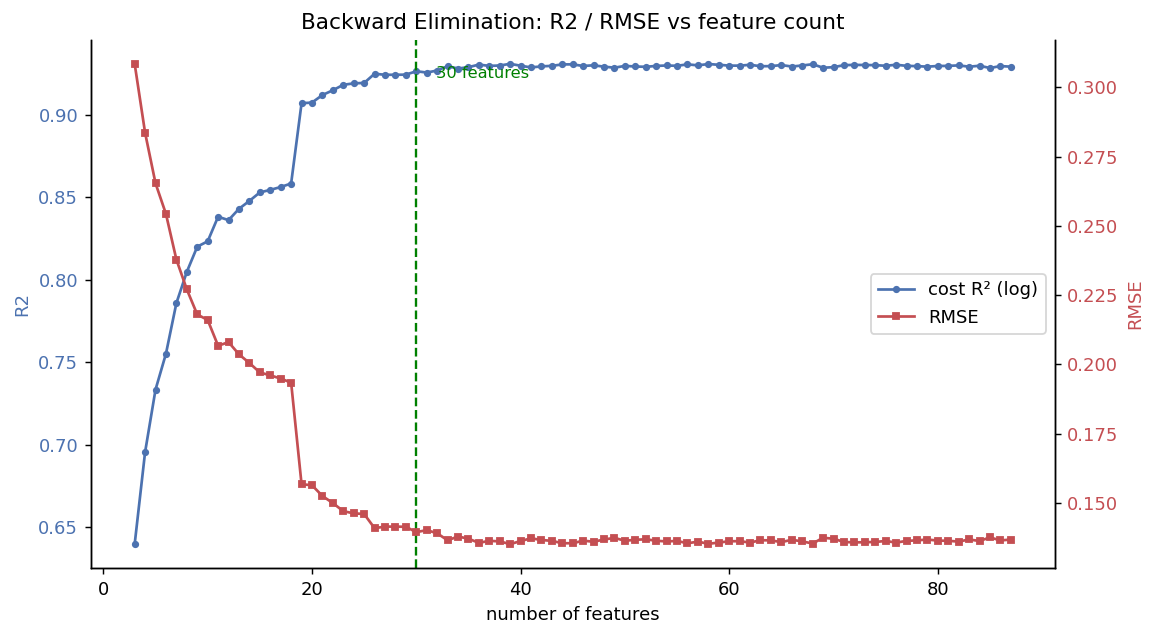

=== feature set (30) ===
sqft..ft2, ashrae_iecc_climate_zone_2004, clothes_dryer, clothes_washer, cooling_setpoint, duct_leakage_and_insulation, geometry_building_number_units_mf, geometry_space_combination, geometry_stories, heating_setpoint, heating_setpoint_offset_period, hot_water_fixtures, hvac_cooling_partial_space_conditioning, hvac_heating_type_and_fuel, infiltration, insulation_roof, insulation_wall, lighting, misc_extra_refrigerator, misc_freezer, misc_hot_tub_spa, misc_pool, occupants, plug_loads, pv_system_size, state, vintage, water_heater_efficiency, window_areas, windows


In [ ]:
# === STEP 7b: the trade-off curve + feature set ===
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False})
BLUE, RED = "#4C72B0", "#C44E52"
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(hist.n, hist.r2, "-o", color=BLUE, ms=3, label="cost R2 (log)")
ax.set_xlabel("number of features"); ax.set_ylabel("R2", color=BLUE)
ax.tick_params(axis="y", labelcolor=BLUE)
ax2 = ax.twinx(); ax2.plot(hist.n, hist.rmse, "-s", color=RED, ms=3, label="RMSE")
ax2.set_ylabel("RMSE", color=RED); ax2.tick_params(axis="y", labelcolor=RED)
ax2.spines["top"].set_visible(False)
ax.axvline(pars_n, color="green", ls="--", lw=1.3)
ax.annotate(f" {pars_n} features", xy=(pars_n, hist.loc[hist.n==pars_n,"r2"].iloc[0]),
            xytext=(8,-4), textcoords="offset points", color="green", fontsize=9)
ax.set_title("Backward Elimination: R2 / RMSE vs feature count")
l1,la1 = ax.get_legend_handles_labels(); l2,la2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, la1+la2, loc="center right"); plt.tight_layout(); plt.show()

print(f"=== feature set ({pars_n}) ===")
print(", ".join(f[3:] for f in pars_feats))

=== Features used in the final (parsimonious) model ===
sqft..ft2,
ashrae_iecc_climate_zone_2004,
clothes_dryer,
clothes_washer,
cooling_setpoint,
duct_leakage_and_insulation,
geometry_building_number_units_mf,
geometry_space_combination,
geometry_stories,
heating_setpoint,
heating_setpoint_offset_period,
hot_water_fixtures,
hvac_cooling_partial_space_conditioning,
hvac_heating_type_and_fuel,
infiltration,
insulation_roof,
insulation_wall,
lighting,
misc_extra_refrigerator,
misc_freezer,
misc_hot_tub_spa,
misc_pool,
occupants,
plug_loads,
pv_system_size,
state,
vintage,
water_heater_efficiency,
window_areas,
windows

Total features: 30


/tmp/ipykernel_487/1920335629.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette="viridis")


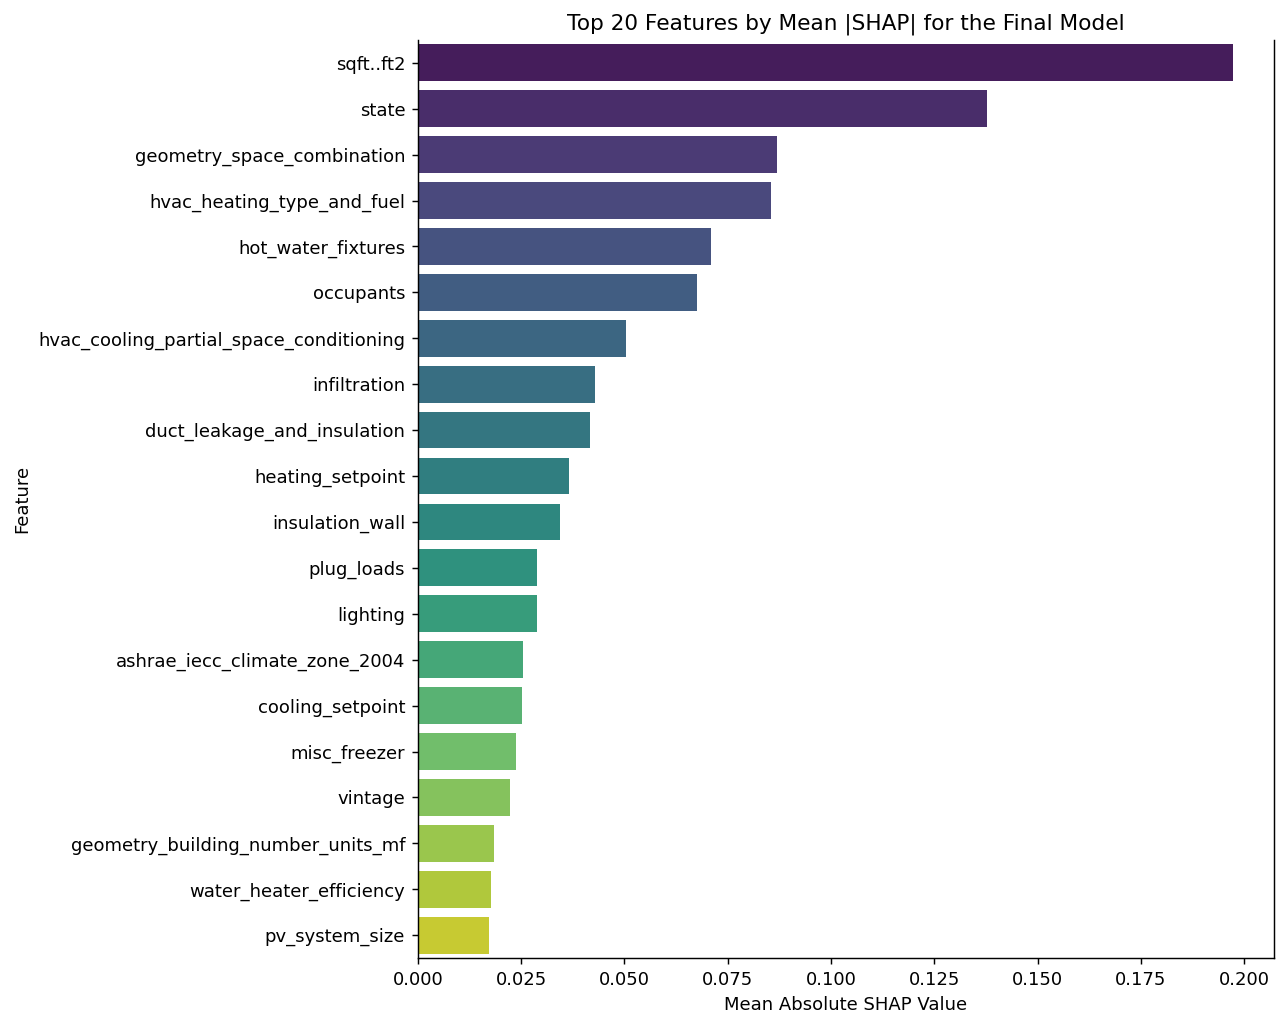

In [ ]:
print("=== Features used in the final model ===")
# Remove 'in.' prefix for better readability
print(",\n".join(f[3:] for f in pars_feats))
print(f"\nTotal features: {len(pars_feats)}")

# Re-run fit_eval_rank to get the SHAP values for the parsimonious model
# This is necessary because 'sh' in the previous cell only contains SHAP values for the last iteration (3 features)
# and not for the 'pars_n' features.
_, _, sh_final = fit_eval_rank(pars_feats)

# Get the top 20 features by mean |SHAP|
top_20_shap_features = sh_final.nlargest(20)

# Generate a visualization showing the top 20 features by mean|shap|
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.dpi":130,"axes.spines.top":False, "figure.figsize":(10, 8)})

# Prepare data for plotting (remove 'in.' prefix from feature names)
plot_data = top_20_shap_features.rename(lambda x: x[3:])

plt.figure()
sns.barplot(x=plot_data.values, y=plot_data.index, palette="viridis")
plt.title("Top 20 Features by Mean |SHAP| for the Final Model")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# === FINAL MODEL CONFIGURATION ===
# copy and pasteable for other notebooks as necessary
# 1. Paths and Targets
S3_PATH = (
    "s3://oedi-data-lake/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2025/"
    "resstock_amy2018_release_1/metadata_and_annual_results/"
    "national/full/parquet/upgrade0.parquet"
)

COST_COL = "out.utility_bills.total_bill..usd"
INCOME_COL = "in.representative_income"

# 2. Selected Features (~30 features)
FINAL_FEATURES = [
    "in.sqft..ft2", "in.ashrae_iecc_climate_zone_2004", "in.clothes_dryer",
    "in.clothes_washer", "in.cooling_setpoint", "in.duct_leakage_and_insulation",
    "in.geometry_building_number_units_mf", "in.geometry_space_combination",
    "in.geometry_stories", "in.heating_setpoint", "in.heating_setpoint_offset_period",
    "in.hot_water_fixtures", "in.hvac_cooling_partial_space_conditioning",
    "in.hvac_heating_type_and_fuel", "in.infiltration", "in.insulation_roof",
    "in.insulation_wall", "in.lighting", "in.misc_extra_refrigerator",
    "in.misc_freezer", "in.misc_hot_tub_spa", "in.misc_pool", "in.occupants",
    "in.plug_loads", "in.pv_system_size", "in.state", "in.vintage",
    "in.water_heater_efficiency", "in.window_areas", "in.windows"
]

# 3. Demographic Features
# Covers income, tenure, vacancy, occupants, etc., for equity analysis and stratification
DEMOGRAPHIC_FEATURES = [
    "in.representative_income",
    "in.income",
    "in.income_recs_2015",
    "in.income_recs_2020",
    "in.area_median_income",
    "in.state_metro_median_income",
    "in.tenure",
    "in.vacancy_status",
    "in.occupants"
]

# 4. Model Hyperparameters
XGB_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "device": "cuda", # Change to 'cpu' if running on a machine without a GPU
    "enable_categorical": True,
    "eval_metric": "rmse",
    "early_stopping_rounds": 30,
    "random_state": 42
}
